<a href="https://colab.research.google.com/github/shishir881/Kamala-River-WaterLevel-Detection-RAN/blob/mock/kamal_project_univariate_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

shishirpuri_kamala_10_min_dataset_path = kagglehub.dataset_download('shishirpuri/kamala-10-min-dataset')

print('Data source import complete.')


100%|██████████| 864k/864k [00:00<00:00, 934kB/s]

Extracting files...
Data source import complete.


In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import kagglehub
import os

In [6]:
filename = '594 Water Level Inst from 2022-01-01 to 2026-06-15.csv'
path = os.path.join(shishirpuri_kamala_10_min_dataset_path, filename)

df = pd.read_csv(path)
df.head()

,dateTime (NPT),value (m)
0,2022-06-08 08:43:58,1.339599967
1,2022-06-08 08:45:00,1.339599967
2,2022-06-14 16:07:22,0
3,2022-06-14 17:26:56,1.61800003052
4,2022-06-15 14:09:12,1.61300003529


In [7]:
# Rename specific columns and update the original DataFrame
df.rename(columns={'dateTime (NPT)': 'dateTime', 'value (m)': 'value'}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176626 entries, 0 to 176625
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   dateTime  176626 non-null  object
 1   value     176626 non-null  object
dtypes: object(2)
memory usage: 2.7+ MB


In [8]:
print(f"Total raw rows loaded: {len(df)}")

print("\nStep 2: Cleaning and formatting Timestamps...")
# Convert 'dateTime' to proper Datetime objects
df['dateTime'] = pd.to_datetime(df['dateTime'], errors='coerce')
df = df.dropna(subset=['dateTime'])

df.set_index('dateTime', inplace=True)
df.sort_index(inplace=True)

print("\nStep 3: Fixing Data Types (The Bug Fix) ...")
# THE FIX: Force the 'value' column to be numeric.
# errors='coerce' turns unconvertible garbage text into NaN instead of crashing.
# Note: Ensure the column name matches exactly what is in your CSV (e.g., 'value (m)' or 'value').
column_name = 'value' # CHANGE THIS to 'value (m)' if that is your exact header in the CSV.
df[column_name] = pd.to_numeric(df[column_name], errors='coerce')

print("\nStep 4: Applying 10-Minute Uniform Grid...")
# Now the .mean() function will work perfectly because it's calculating on floats, not text.
df_uniform = df.resample('10min').mean()

print("\n--- Process Complete ---")
print(f"Total rows in uniform grid: {len(df_uniform)}")
print(f"Start Date: {df_uniform.index.min()}")
print(f"End Date: {df_uniform.index.max()}")
print(f"Total missing intervals (NaNs) found in {column_name}: {df_uniform[column_name].isnull().sum()}")


Total raw rows loaded: 176626

Step 2: Cleaning and formatting Timestamps...

Step 3: Fixing Data Types (The Bug Fix) ...

Step 4: Applying 10-Minute Uniform Grid...

--- Process Complete ---
Total rows in uniform grid: 179499
Start Date: 2022-06-08 08:40:00
End Date: 2025-11-05 21:00:00
Total missing intervals (NaNs) found in value: 3252


In [9]:
df_uniform.tail()

,value
dateTime,
2025-11-05 20:20:00,1.618000
2025-11-05 20:30:00,1.617000
2025-11-05 20:40:00,1.620000
2025-11-05 20:50:00,1.617667
2025-11-05 21:00:00,1.617000


In [10]:
print("Step 1: Analyzing Outliers (Garbage Values)")
# Count how many weird values exist
outlier_mask = (df_uniform['value'] > 20) | (df_uniform['value'] < 0.3)
total_outliers = outlier_mask.sum()
print(f"Total Outliers found (Height > 20m or < 0.3m): {total_outliers}")

# ---------------------------------------------------------
# STEP 2: THE "SMART FIX" (Replacing outliers with NaN temporarily)
# ---------------------------------------------------------
# Hami outlers lai paila NaN banauchau
df_uniform.loc[outlier_mask, 'value'] = np.nan

# ---------------------------------------------------------
# STEP 3: LOCAL INTERPOLATION (Fixing small glitches ONLY)
# ---------------------------------------------------------
print("\nStep 3: Applying Smart Local Smoothing...")
# Interpolate method='linear' le agadi-pachadi ko line jodhcha.
# limit=4 ko matlab: yadi lagatar 4 ota (40 mins) samma matra NaN cha bhane teslai fill garne.
# Yadi timile vanya jasto 30-35 ota lagatar NaN cha bhane, yesle fill gardaina!
df_uniform['value'] = df_uniform['value'].interpolate(method='linear', limit=6)

# Aba check garau kati wata NaN baki chan (jun lamo errors thiyo)
remaining_nans = df_uniform['value'].isnull().sum()
print(f"Small glitches fixed successfully without breaking sequences!")
print(f"Remaining large errors (which will break sequences during chunking): {remaining_nans}")

# ---------------------------------------------------------
# STEP 4: VERIFY CLEAN DATA
# ---------------------------------------------------------
print(f"\nNew Clean Max Height: {df_uniform['value'].max():.2f} meters")
print(f"New Clean Min Height: {df_uniform['value'].min():.2f} meters")

Step 1: Analyzing Outliers (Garbage Values)
Total Outliers found (Height > 20m or < 0.3m): 4682

Step 3: Applying Smart Local Smoothing...
Small glitches fixed successfully without breaking sequences!
Remaining large errors (which will break sequences during chunking): 6589

New Clean Max Height: 5.46 meters
New Clean Min Height: 1.05 meters


In [11]:
# ---------------------------------------------------------
# STEP 1: THE CHUNKING ALGORITHM
# ---------------------------------------------------------
def split_into_valid_chunks(df, column_name='value', min_length=36):
    """
    NaN aayeko thau ma data lai break garchha.
    Yadi chunk ko length 36 (6 hours) bhanda sano cha bhane discard garcha.
    """
    valid_chunks = []
    current_chunk = []

    # Iterate through the DataFrame values
    values = df[column_name].values

    for val in values:
        if pd.notna(val):
            # Yadi number ho bhane, current chunk ma jodne
            current_chunk.append(val)
        else:
            # Yadi NaN aayo bhane, gap bhetthyo!
            # Paila check garne current_chunk lamo cha ki chaina
            if len(current_chunk) > min_length:
                valid_chunks.append(np.array(current_chunk))
            # Current chunk lai khali (reset) garne next valid block ko lagi
            current_chunk = []

    # Loop sakiye pachi last ko bacheko chunk check garne
    if len(current_chunk) > min_length:
        valid_chunks.append(np.array(current_chunk))

    return valid_chunks

# Hamro lag time 36 ho (6 hours)
time_step = 36
print("Running Chunking Algorithm...")
chunks = split_into_valid_chunks(df_uniform, column_name='value', min_length=time_step)

print(f"\n✅ Success! Data split into {len(chunks)} completely safe, continuous chunks.")

# ---------------------------------------------------------
# STEP 2: LETS SEE WHAT A CHUNK LOOKS LIKE
# ---------------------------------------------------------
# Paila 5 wata chunks ko length herau
print("\nLengths of the first 5 chunks:")
for i in range(min(5, len(chunks))):
    print(f"Chunk {i+1}: {len(chunks[i])} data points ({len(chunks[i])*10/60:.1f} hours of continuous data)")

total_valid_points = sum(len(c) for c in chunks)
print(f"\nTotal safe data points we rescued: {total_valid_points}")
print(f"Total points discarded (NaNs + tiny chunks): {len(df) - total_valid_points}")

Running Chunking Algorithm...

✅ Success! Data split into 58 completely safe, continuous chunks.

Lengths of the first 5 chunks:
Chunk 1: 91 data points (15.2 hours of continuous data)
Chunk 2: 46 data points (7.7 hours of continuous data)
Chunk 3: 200 data points (33.3 hours of continuous data)
Chunk 4: 113 data points (18.8 hours of continuous data)
Chunk 5: 35740 data points (5956.7 hours of continuous data)

Total safe data points we rescued: 171843
Total points discarded (NaNs + tiny chunks): 4783


In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM,Dropout
import matplotlib.pyplot as plt
print("Step 1: Splitting Chunks and Normalizing (No Data Leakage)...")

# 1. Paila Chunks lai Train ra Test ma divide garne (Chronological Split: 80% Train, 20% Test)
split_index = int(len(chunks) * 0.9)
train_chunks = chunks[:split_index]
test_chunks = chunks[split_index:]

print(f"Total Chunks: {len(chunks)} | Train Chunks: {len(train_chunks)} | Test Chunks: {len(test_chunks)}")

# 2. Train chunks lai matra jodera Scaler lai 'fit' garne (Sikaune)
train_data_combined = np.concatenate(train_chunks).reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data_combined) # Yaha Scaler le Test data ko barema kei pani dekhna paudaina (No cheating!)

# 3. Aba Train ra Test dubai lai tehi train-scaler le transform (scale) garne
scaled_train_chunks = [scaler.transform(chunk.reshape(-1, 1)) for chunk in train_chunks]
scaled_test_chunks = [scaler.transform(chunk.reshape(-1, 1)) for chunk in test_chunks]

print("✅ Split and Normalization Complete!")

Step 1: Splitting Chunks and Normalizing (No Data Leakage)...
Total Chunks: 58 | Train Chunks: 52 | Test Chunks: 6
✅ Split and Normalization Complete!


In [13]:
print("\nStep 2: Creating 3D Sliding Windows (X and y) for LSTM...")
time_step = 36 # 6 hours history (36 * 10 mins)

# Sequence banaune reusable function (Dry Run Principle)
def make_sequences(scaled_chunks, time_step):
    X_list, y_list = [], []
    for chunk in scaled_chunks:
        # Harek chunk bata past 'time_step' steps ra next '1' target nikalne
        for i in range(len(chunk) - time_step):
            X_list.append(chunk[i:(i + time_step), 0]) # Past 36 steps
            y_list.append(chunk[i + time_step, 0])     # Next 1 step (Target)
    return np.array(X_list), np.array(y_list)

print("Generating sequences for Training data...")
X_train, y_train = make_sequences(scaled_train_chunks, time_step)

print("Generating sequences for Testing data...")
X_test, y_test = make_sequences(scaled_test_chunks, time_step)

# LSTM lai data 3D shape ma chahincha: [samples, time_steps, features]
# Hami sanga ahile sirf 1 feature (Water Level) cha, tesaile last ma '1' haleko
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("\n✅ Sequence Generation Complete! Data is ready for Model.")
print("-" * 50)
print("FUNDAMENTAL DATA INFO:")
print("-" * 50)
print(f"Time Step (Lag)          : {time_step} intervals (6 hours)")
print(f"Shape of X_train (Input) : {X_train.shape} -> (Total Windows, Time Steps, Features)")
print(f"Shape of y_train (Target): {y_train.shape} -> (Total Targets)")
print(f"Shape of X_test (Input)  : {X_test.shape}")
print(f"Shape of y_test (Target) : {y_test.shape}")
print("-" * 50)


Step 2: Creating 3D Sliding Windows (X and y) for LSTM...
Generating sequences for Training data...
Generating sequences for Testing data...

✅ Sequence Generation Complete! Data is ready for Model.
--------------------------------------------------
FUNDAMENTAL DATA INFO:
--------------------------------------------------
Time Step (Lag)          : 36 intervals (6 hours)
Shape of X_train (Input) : (117024, 36, 1) -> (Total Windows, Time Steps, Features)
Shape of y_train (Target): (117024,) -> (Total Targets)
Shape of X_test (Input)  : (52731, 36, 1)
Shape of y_test (Target) : (52731,)
--------------------------------------------------


In [14]:
# ---------------------------------------------------------
# STEP 4: DESIGNING THE LSTM MODEL
# ---------------------------------------------------------
print("\nStep 4: Building the LSTM Architecture...")
model = Sequential()

# Layer 1 (LSTM le pattern sikcha)
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2)) # Overfitting garna bata rokcha

# Layer 2 (Deep learning)
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))

# Final Output Layer (1 number predict garne)
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
print("✅ Model Architecture Ready!")


Step 4: Building the LSTM Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ Model Architecture Ready!


In [15]:
# ---------------------------------------------------------
# STEP 5: TRAINING THE MODEL
# ---------------------------------------------------------
from tensorflow.keras.callbacks import EarlyStopping
# EarlyStopping le model ko error ghatna chhodyo bhane training aafai stop garcha
# ra sabai bhanda best result (weights) lai restore garcha.
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,  # 5 epoch samma error ghatena bhane stop garne
                           restore_best_weights=True)

print("\nTraining Model (Allowing up to 40 Epochs for full convergence)...")
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=40, # 5 bata 40 banayeko
                    batch_size=64,
                    callbacks=[early_stop], # Adding the smart stopper
                    verbose=1)

print("\n✅ Training Complete!")


Training Model (Allowing up to 40 Epochs for full convergence)...
Epoch 1/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: 3.0123e-04 - val_loss: 7.7426e-05
Epoch 2/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 1.4026e-04 - val_loss: 7.4141e-05
Epoch 3/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 1.2644e-04 - val_loss: 8.1408e-05
Epoch 4/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - loss: 1.2005e-04 - val_loss: 8.9397e-05
Epoch 5/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 1.2412e-04 - val_loss: 7.4897e-05
Epoch 6/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 1.1567e-04 - val_loss: 7.2676e-05
Epoch 7/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 1.1644e-04 - val_loss: 5.7065e-05
Epoch 8/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 1.1465e-04 - val_loss: 6.2957e-05
Epoch 9/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 1.1217e-04 - val_loss: 5.6423e-05
Epoch 10/40
1829/1829 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms

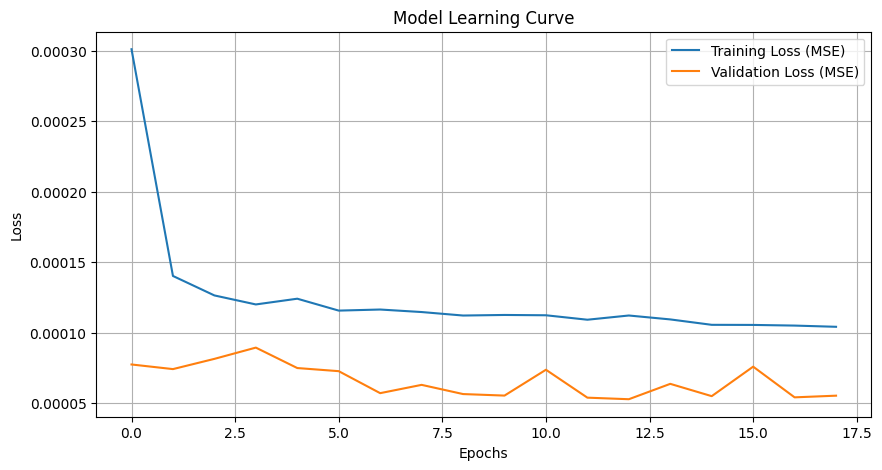

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Step 1: Generating Predictions on Test Set...
1648/1648 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
Step 2: Inverse Transforming (0-1 back to Real Meters)...

--- MODEL PERFORMANCE (REAL WORLD METRICS) ---
RMSE (Root Mean Squared Error): 0.0318 meters
MAE (Mean Absolute Error)     : 0.0114 meters
(Matlab: Timro model le average ma 1.1 cm ko matra mistake garcha!)

Step 4: Plotting Actual vs Predicted...


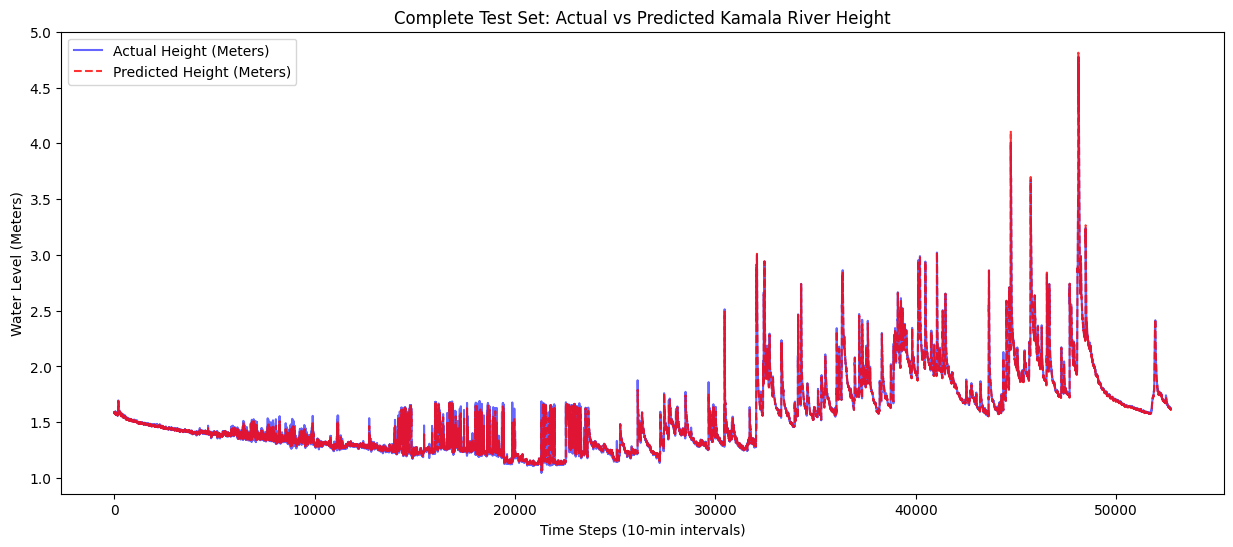

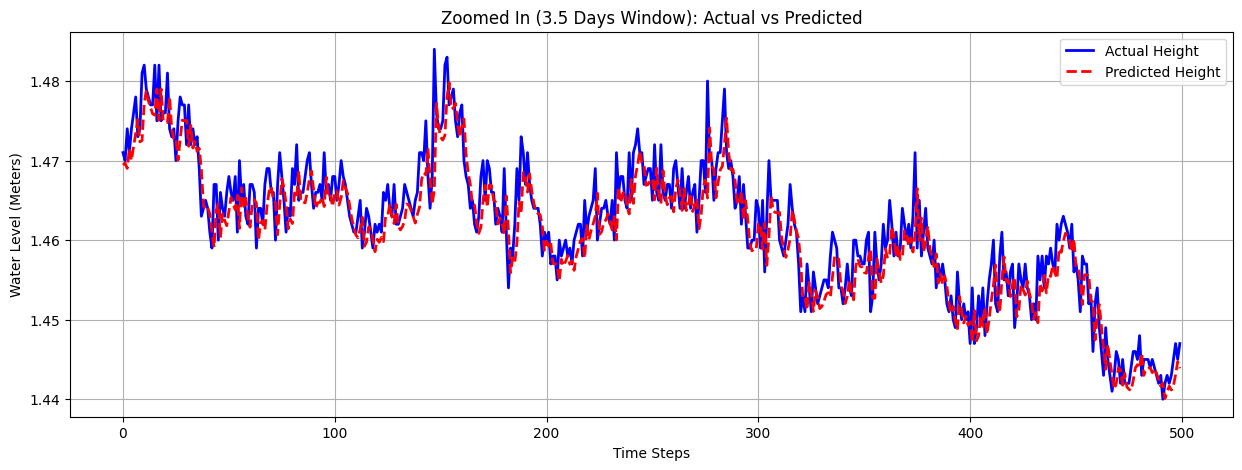

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

print("Step 1: Generating Predictions on Test Set...")
# Test set ma bholi ko height predict garne
predictions = model.predict(X_test)

print("Step 2: Inverse Transforming (0-1 back to Real Meters)...")
# Model le 0-1 scale ma deko prediction lai actual meters ma convert garne
predictions_real = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# ---------------------------------------------------------
# STEP 3: CALCULATING ACCURACY METRICS (IN METERS)
# ---------------------------------------------------------
# RMSE (Root Mean Squared Error) ra MAE (Mean Absolute Error) nikalne
rmse = math.sqrt(mean_squared_error(y_test_real, predictions_real))
mae = mean_absolute_error(y_test_real, predictions_real)

print("\n--- MODEL PERFORMANCE (REAL WORLD METRICS) ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f} meters")
print(f"MAE (Mean Absolute Error)     : {mae:.4f} meters")
print(f"(Matlab: Timro model le average ma {mae*100:.1f} cm ko matra mistake garcha!)")

# ---------------------------------------------------------
# STEP 4: PLOTTING THE RESULTS
# ---------------------------------------------------------
print("\nStep 4: Plotting Actual vs Predicted...")

# Plot 1: Overall Test Data (Sabai 35,000+ points)
plt.figure(figsize=(15, 6))
plt.plot(y_test_real, color='blue', label='Actual Height (Meters)', alpha=0.6)
plt.plot(predictions_real, color='red', label='Predicted Height (Meters)', alpha=0.8, linestyle='dashed')
plt.title('Complete Test Set: Actual vs Predicted Kamala River Height')
plt.xlabel('Time Steps (10-min intervals)')
plt.ylabel('Water Level (Meters)')
plt.legend()
plt.show()

# Plot 2: Zoomed-in View (Because Plot 1 might look like a crowded blob)
# Hami jamma 500 steps (approx 3.5 days) ko slice herchau jaha ali fluctuation cha
start_zoom = 2000 # Random start point, timi aafai change garera farak thau herna sakchau
end_zoom = 2500

plt.figure(figsize=(15, 5))
plt.plot(y_test_real[start_zoom:end_zoom], color='blue', label='Actual Height', linewidth=2)
plt.plot(predictions_real[start_zoom:end_zoom], color='red', label='Predicted Height', linewidth=2, linestyle='dashed')
plt.title('Zoomed In (3.5 Days Window): Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Water Level (Meters)')

plt.legend()
plt.grid(True)
plt.show()